LAB 8 PAVVIT SINGH BATRA ROLL:8

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
categories=pd.read_excel('northwind.xlsx', sheet_name='categories')
products=pd.read_excel('northwind.xlsx', sheet_name='products')
order_details=pd.read_excel('northwind.xlsx', sheet_name='order_details')
orders=pd.read_excel('northwind.xlsx', sheet_name='orders')
employees=pd.read_excel('northwind.xlsx', sheet_name='employees')
customers=pd.read_excel('northwind.xlsx', sheet_name='customers')
shippers=pd.read_excel('northwind.xlsx', sheet_name='shippers')
employeeterritories=pd.read_excel('northwind.xlsx', sheet_name='employeeterritories')
territories=pd.read_excel('northwind.xlsx', sheet_name='territories')
region=pd.read_excel('northwind.xlsx', sheet_name='region')
suppliers=pd.read_excel('northwind.xlsx', sheet_name='suppliers')

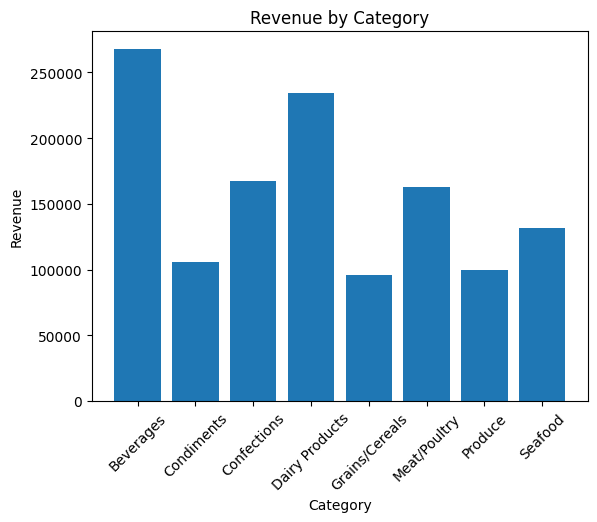

In [11]:
merged = categories.merge(products, on='categoryid') \
.merge(order_details, on='productid')
merged['Revenue'] = merged['unitprice_y'] * merged['quantity'] * (1 - merged['discount'])
revenue_by_category = merged.groupby('categoryname')['Revenue'].sum().reset_index()
plt.figure()
plt.bar(revenue_by_category['categoryname'], revenue_by_category['Revenue'])
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.title('Revenue by Category')
plt.xticks(rotation=45)
plt.show()

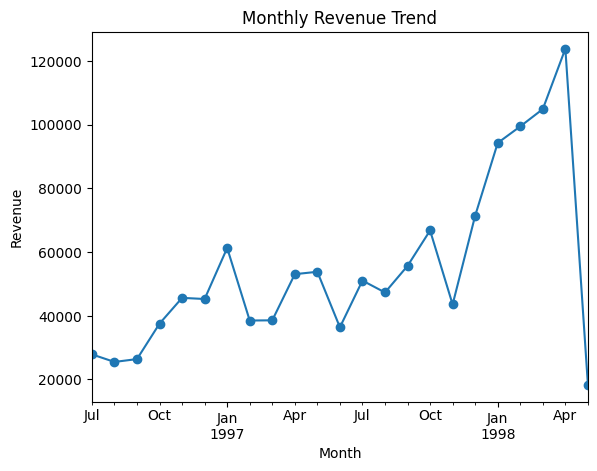

In [9]:
df = pd.merge(orders, order_details, on='orderid')
df['orderdate'] = pd.to_datetime(df['orderdate'])
df['Revenue'] = df['unitprice'] * df['quantity'] * (1 - df['discount'])
monthly = df.groupby(df['orderdate'].dt.to_period('M'))['Revenue'].sum()
monthly.plot(marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

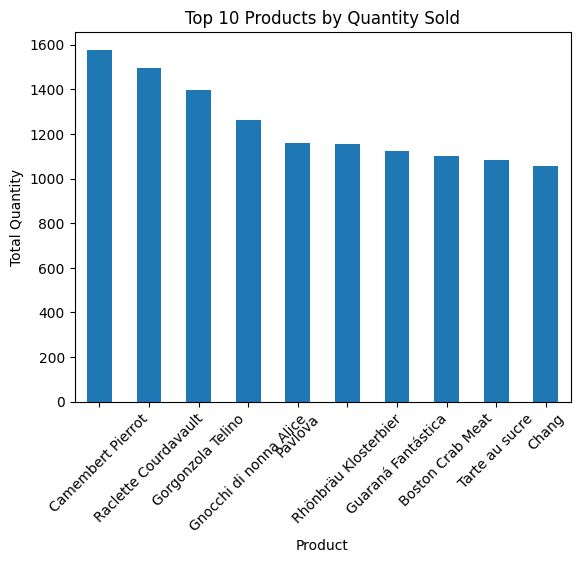

In [10]:
df = pd.merge(products, order_details, on='productid')
top_products = df.groupby('productname')['quantity'].sum().nlargest(10)
top_products.plot(kind='bar')
plt.xticks(rotation=45)
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Product')
plt.ylabel('Total Quantity')
plt.show()

   customerid   TotalSpend  TotalOrders
60      QUICK  110277.3050           28
19      ERNSH  104874.9785           30
68      SAVEA  104361.9500           31
62      RATTC   51097.8005           18
35      HUNGO   49979.9050           19
32      HANAR   32841.3700           14
37      KOENE   30908.3840           14
22      FOLKO   29567.5625           19
49      MEREP   28872.1900           13
86      WHITC   27363.6050           14


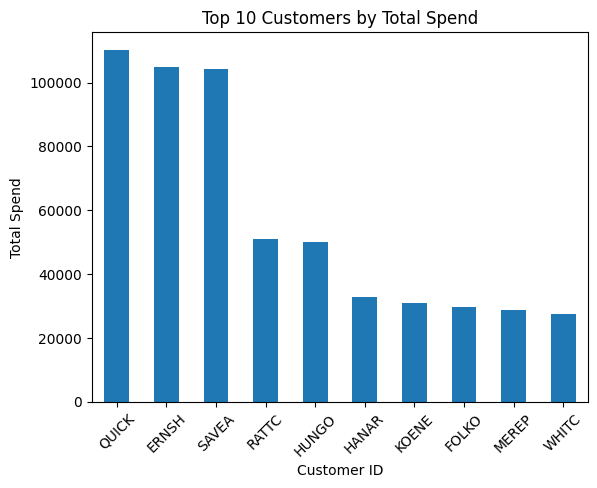

In [27]:
df = customers.merge(orders, on='customerid').merge(order_details, on='orderid')

df['Revenue'] = df['unitprice'] * df['quantity'] * (1 - df['discount'])

result = df.groupby('customerid').agg(
    TotalSpend=('Revenue', 'sum'),
    TotalOrders=('orderid', 'nunique')
).reset_index()

top10 = result.sort_values(by='TotalSpend', ascending=False).head(10)
print(top10)

top10.set_index('customerid')['TotalSpend'].plot(kind='bar')

plt.xticks(rotation=45)
plt.title('Top 10 Customers by Total Spend')
plt.xlabel('Customer ID')
plt.ylabel('Total Spend')
plt.show()

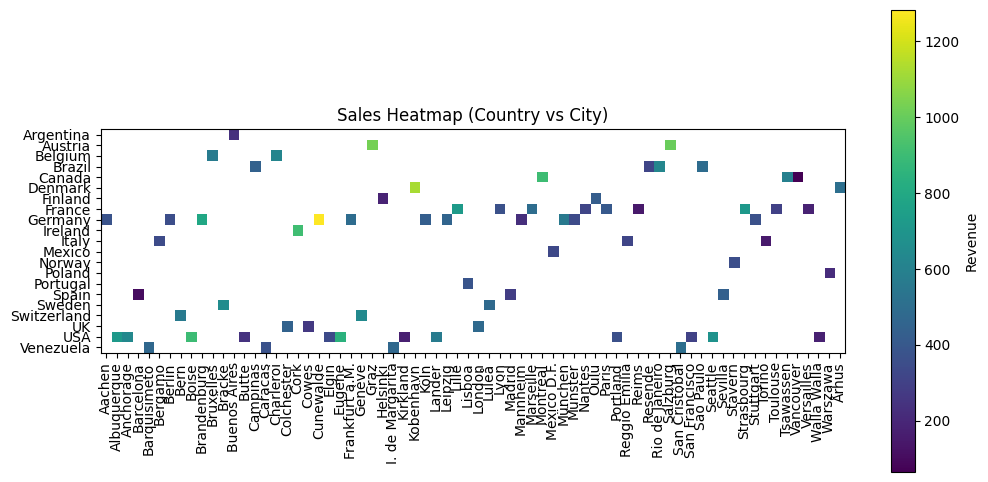

In [15]:
df = pd.merge(orders, order_details, on='orderid')
df['Revenue'] = df['unitprice'] * df['quantity'] * (1 - df['discount'])
heatmap_data = df.pivot_table(values='Revenue', index='shipcountry', columns='shipcity')
plt.figure(figsize=(12,6))
plt.imshow(heatmap_data)
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=90)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.title('Sales Heatmap (Country vs City)')
plt.colorbar(label='Revenue')
plt.show()

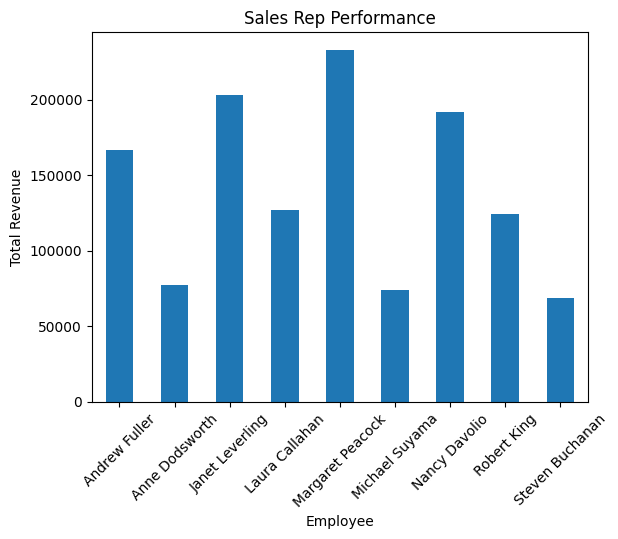

In [17]:
df = employees.merge(orders, on='employeeid').merge(order_details, on='orderid')
df['Revenue'] = df['unitprice'] * df['quantity'] * (1 - df['discount'])
employee_perf = df.groupby(df['firstname'] + ' ' + df['lastname'])['Revenue'].sum()
employee_perf.plot(kind='bar')
plt.xticks(rotation=45)
plt.title('Sales Rep Performance')
plt.xlabel('Employee')
plt.ylabel('Total Revenue')
plt.show()

companyname
Federal Shipping    7.473896
Speedy Express      8.571429
United Package      9.234921
Name: DeliveryTime, dtype: float64


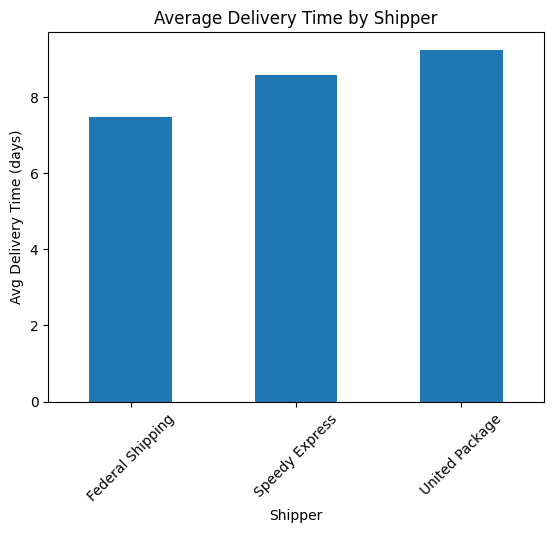

In [18]:
df = orders.merge(shippers, left_on='shipvia', right_on='shipperid')
df['orderdate'] = pd.to_datetime(df['orderdate'])
df['shippeddate'] = pd.to_datetime(df['shippeddate'])
df['DeliveryTime'] = (df['shippeddate'] - df['orderdate']).dt.days
result = df.groupby('companyname')['DeliveryTime'].mean().sort_values()
print(result)
result.plot(kind='bar')
plt.xticks(rotation=45)
plt.title('Average Delivery Time by Shipper')
plt.xlabel('Shipper')
plt.ylabel('Avg Delivery Time (days)')
plt.show()

  regiondescription  EmployeeCount
0           Eastern              4
1          Northern              2
2          Southern              1
3           Western              2


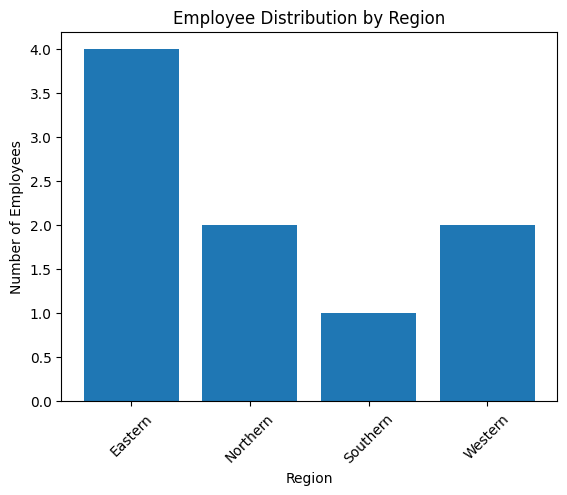

In [21]:
df = region.merge(territories, on='regionid') \
.merge(employeeterritories, on='territoryid') \
.merge(employees, on='employeeid')
result = df.groupby('regiondescription')['employeeid'].nunique().reset_index(name='EmployeeCount')
print(result)
plt.figure()
plt.bar(result['regiondescription'], result['EmployeeCount'])
plt.xlabel('Region')
plt.ylabel('Number of Employees')
plt.title('Employee Distribution by Region')
plt.xticks(rotation=45)
plt.show()

                               companyname  TotalProducts  TotalInventoryValue
0               Aux joyeux ecclésiastiques              2              5721.50
1                        Bigfoot Breweries              3              2642.00
2       Cooperativa de Quesos 'Las Cabras'              2              3730.00
3                       Escargots Nouveaux              1               821.50
4                           Exotic Liquids              2               453.00
5                  Formaggi Fortini s.r.l.              3               775.20
6                         Forêts d'érables              2              4058.60
7                              G'day, Mate              3              1326.00
8                             Gai pâturage              2              4991.00
9                Grandma Kelly's Homestead              3              3690.00
10             Heli Süßwaren GmbH & Co. KG              3              3683.55
11                               Karkki Oy          

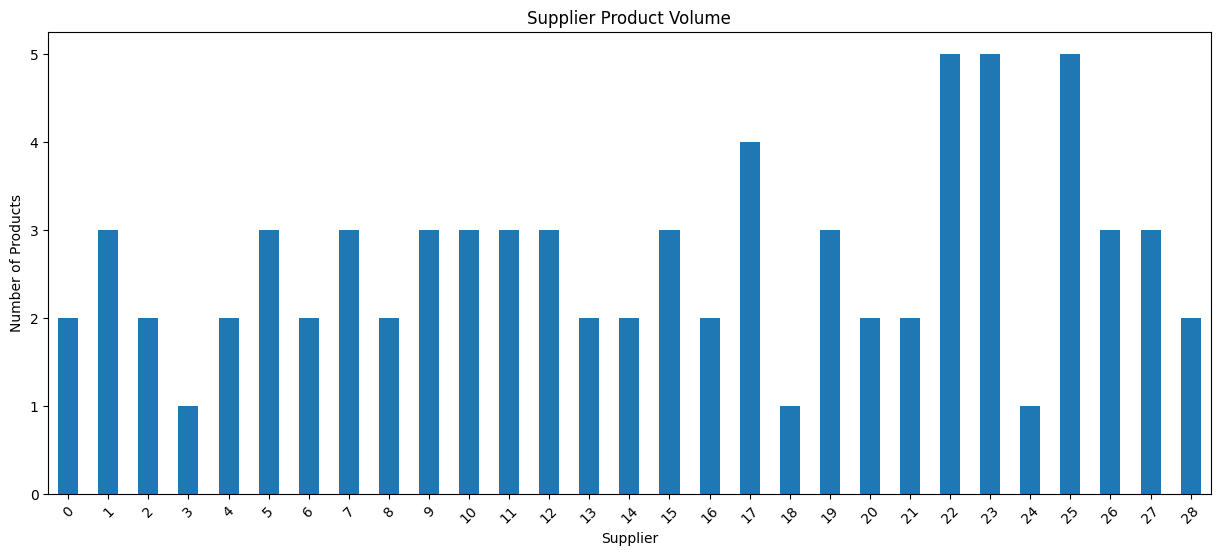

In [23]:
df = suppliers.merge(products, on='supplierid')
df['InventoryValue'] = df['unitsinstock'] * df['unitprice']
result = df.groupby('companyname').agg(TotalProducts=('productid', 'count'),TotalInventoryValue=('InventoryValue', 'sum')
).reset_index()
print(result)
result['TotalProducts'].plot(kind='bar', figsize=(15,6))
plt.xticks(rotation=45)
plt.title('Supplier Product Volume')
plt.xlabel('Supplier')
plt.ylabel('Number of Products')
plt.show()

correlation: 0.12857659773695085


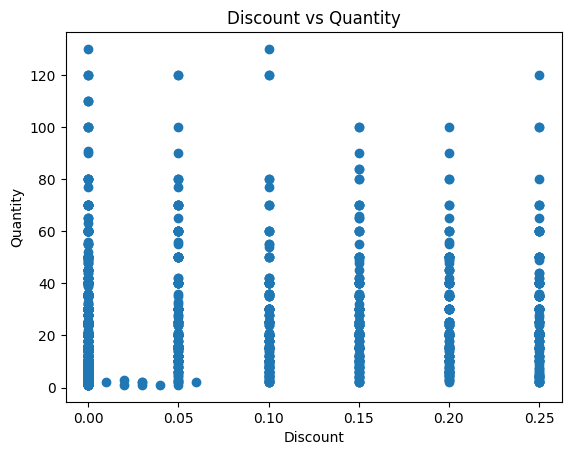

In [25]:
df = order_details.copy()
correlation = df['discount'].corr(df['quantity'])
print("correlation:",correlation)
plt.figure()
plt.scatter(df['discount'], df['quantity'])
plt.xlabel('Discount')
plt.ylabel('Quantity')
plt.title('Discount vs Quantity')
plt.show()